Size (width, height): (28, 28)
Mode: L
Array shape: (28, 28)
Data type: uint8
Min pixel: 0
Max pixel: 255
Mean: 62.09311224489796
Std: 105.19839252238374


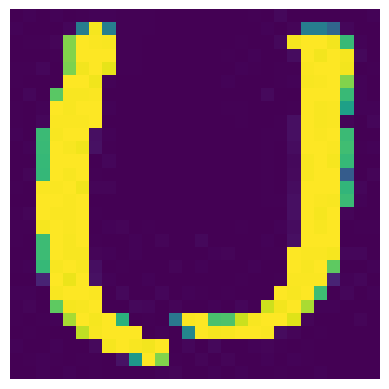

In [36]:
import os
import cv2
# use pillow for less strict decoding policynpm i -g @openai/codex
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader


base = r"C:\Users\XPS\Downloads\Amharic Dataset\uni_dataset"
folders = os.listdir(base)
folder = folders[0]
path = os.path.join(base, folder)
file = os.listdir(path)[1]
img_path = os.path.join(path, file)

img = cv2.imread(img_path)
# print(img_path)

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
arr = np.array(img)

print("Size (width, height):", img.size)
print("Mode:", img.mode)
print("Array shape:", arr.shape)
print("Data type:", arr.dtype)
print("Min pixel:", arr.min())
print("Max pixel:", arr.max())
print("Mean:", arr.mean())
print("Std:", arr.std())

In [37]:
# Normalization - preparing the data for use
# DatasetNormalization - mean-std normalization for stability + faster convergence

pixel_sum = 0.0
pixel_sq_sum = 0.0
count = 0 # total number of pixels seen

for cls in os.listdir(base):
    cls_path = os.path.join(base, cls)
    
    for fname in os.listdir(cls_path):
        path = os.path.join(cls_path, fname)

        try: 
            img = Image.open(path).convert("L") # convert to grayscale
            arr = np.array(img, dtype=np.float32) # convert to NumPy array
            arr = arr / 255.0

            pixel_sum += arr.sum()
            pixel_sq_sum += (arr ** 2).sum()
            count += arr.size

        except:
            continue

mean = pixel_sum / count
std = np.sqrt(pixel_sq_sum / count - mean ** 2)

print("Min:", arr.min())
print("Max:", arr.max())
print("Dtype:", arr.dtype)
print("Dataset mean:", mean)
print("Dataset std:", std)          

Min: 0.0
Max: 1.0
Dtype: float32
Dataset mean: 0.23909761
Dataset std: 0.40737632


In [38]:
# Checking for impage imbalance form each folder or character
counts = {}
for folder in folders:
    folder_path = os.path.join(base, folder)
    folder_as_list = os.listdir(folder_path)
    counts[folder] = len(folder_as_list)

values = list(counts.values())
max_value = max(values)
min_value = min(values)
print("Max Value:", max_value)
print("Min Value:", min_value)
print("Imbalance Ratio:", max_value // min_value)

'''
Ratio	Meaning
< 3×	mild / acceptable
≈ 5×	moderate imbalance ← here
≥ 10×	severe imbalance

Decision --> Accept the imbalance and hope the network learns anyway.
'''

Max Value: 321
Min Value: 64
Imbalance Ratio: 5


'\nRatio\tMeaning\n< 3×\tmild / acceptable\n≈ 5×\tmoderate imbalance ← here\n≥ 10×\tsevere imbalance\n\nDecision --> Accept the imbalance and hope the network learns anyway.\n'

In [39]:
# Dataset Implmenetation  - impromvemnt from up to know 

class AmharicHandwritingDataset(Dataset):
    def __init__(self, root_dir, mean, std):
        self.samples = []
        self.mean = mean
        self.std = std

        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_path):
                path = os.path.join(cls_path, fname)
                self.samples.append((path, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path).convert("L")   # grayscale
        arr = np.array(img, dtype=np.float32) / 255.0

        # mean–std normalization
        arr = (arr - self.mean) / self.std

        x = torch.from_numpy(arr).unsqueeze(0)  # [1, H, W]
        y = torch.tensor(label, dtype=torch.long)

        return x, y


In [40]:
# create the dataset object & split train and validation 80/20
dataset = AmharicHandwritingDataset(root_dir=base, mean=mean, std=std)

from torch.utils.data import random_split

total_size = len(dataset)

# 80/20 split
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split( dataset, [train_size, val_size])
print("Training Samples:", len(train_dataset))
print("validation Samples:", len(val_dataset))

'''
Images ✔
Labels from folder names ✔
Grayscale + scaling ✔
Dataset mean / std ✔
Dataset class ✔
Train / Val split ✔

'''

Training Samples: 30121
validation Samples: 7531


'\nImages ✔\nLabels from folder names ✔\nGrayscale + scaling ✔\nDataset mean / std ✔\nDataset class ✔\nTrain / Val split ✔\n\n'

In [41]:
# Augmentation 
from torchvision import transforms
import torch

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),

    # ---- Light augmentation ----
    transforms.RandomAffine(
        degrees=7,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),

    transforms.ToTensor(),

    # tiny Gaussian noise
    transforms.Lambda(lambda x: x + 0.02 * torch.randn_like(x)),

    # normalization
    transforms.Normalize(mean=[mean], std=[std])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])
])

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform   = val_transform

In [42]:

# Model architecturally

# For handwriting recognition with 237 classes, a solid baseline must include:

# 1️⃣ Multiple convolution blocks
# Not just one or two layers — you need hierarchical features:

# edges → strokes → parts → characters

# 2️⃣ Normalization
# So training stays stable and converges faster.

# 3️⃣ Regularization
# So you don’t overfit while chasing high accuracy.

# 4️⃣ Controlled depth
# Enough to learn complex shapes, not so deep that it becomes untrainable
# """

# """
# Our baseline design:
# We will have Three blocks:
# where each block will have: 
#     1. Convulation
#     2. Normalization
#     3. ReLU
#     4. Convolution
#     5. Normalization 
#     6. ReLU
#     7. Max Pool

# gradually compressing the file from 28 by 28 -> 14 by 14 -> 7 by 7 -> 3 by 3
# Final architecture blueprint (no code yet)

# This is what we are about to build conceptually:

# Input 1×28×28
#   ↓
# Conv(1 → 64) + BatchNorm + LeakyReLU + MaxPool
#   ↓
# Conv(64 → 128) + BatchNorm + LeakyReLU + MaxPool
#   ↓
# Conv(128 → 256) + BatchNorm + LeakyReLU
#   ↓
# Global Average Pooling
#   ↓
# Fully Connected → 237 classes

# Why this works
# 64–128–256 channels → enough capacity to model 237 classes
# BatchNorm → stabilizes training & allows higher learning rates
# LeakyReLU → preserves gradients on faint strokes
# Global Average Pooling → prevents overfitting to position

# One final FC layer → clean classifier head

In [43]:

# Convolutional Block Design 
import torch
import torch.nn as nn
import torch.nn.functional as F

class Block1(nn.Module):
    def __init__(self):
        super(Block1, self).__init__()
        self.weight = nn.Parameter(torch.randn(32, 1, 3, 3))
        self.bias = nn.Parameter(torch.zeros(32))

        self.bn = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # convolution 
        x = F.conv2d(
            x, 
            self.weight,
            self.bias,
            stride=1, 
            padding=1
        )

        # Normalization
        x = self.bn(x)
        # Activation
        x = F.leaky_relu(x)
        # max pooling
        x = self.pool(x)
        # Dropout
        x = self.dropout(x)
        return x

class Block2(nn.Module):
    def __init__(self):
        super(Block2, self).__init__()
        self.weight = nn.Parameter(torch.randn(64, 32, 3, 3))
        self.bias = nn.Parameter(torch.zeros(64))

        self.bn = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.15)

    def forward(self, x):
        x = F.conv2d(
            x,
            self.weight,
            self.bias,
            stride=1,
            padding=1
        )

        x = self.bn(x)
        x = F.leaky_relu(x)
        x = self.pool(x)
        x = self.dropout(x)
        return x

class Block3(nn.Module):
    def __init__(self):
        super(Block3, self).__init__()
        self.weight = nn.Parameter(torch.randn(128, 64, 3, 3))
        self.bias = nn.Parameter(torch.zeros(128))

        self.bn = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = F.conv2d(
            x,
            self.weight,
            self.bias,
            stride=1,
            padding=1
        )

        x = self.bn(x)
        x = F.leaky_relu(x)
        x = self.pool(x)
        x = self.dropout(x)
        return x

class Block4(nn.Module):
    def __init__(self):
        super(Block4, self).__init__()
        self.weight = nn.Parameter(torch.randn(256, 128, 3, 3))
        self.bias = nn.Parameter(torch.zeros(256))

        self.bn = nn.BatchNorm2d(256)

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = F.conv2d(
            x,
            self.weight,
            self.bias,
            stride=1,
            padding=1
        )
        x = self.bn(x)
        x = F.leaky_relu(x)

        x = self.dropout(x)
        return x

In [44]:
# Amharic Handwriting detetciton class
class AHCNN(nn.Module):
    def __init__(self, num_classes=237):
        super().__init__()

        self.block1 = Block1()
        self.block2 = Block2()
        self.block3 = Block3()
        self.block4 = Block4()

        # Adaptive average pooling
        self.gap = nn.AdaptiveAvgPool2d(1)
        # Classifier: 256 feature maps → 237 classes
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", device)
model = AHCNN().to(device)
# print(next(model.parameters()).device)
# dummy = torch.randn(4, 1, 28, 28).to("cuda")
# out = model(dummy)
# print(out.shape)


In [46]:
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

# loss + optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


In [66]:
import matplotlib.pyplot as plt

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

epochs = 1
count_train = count_val =  0
for epoch in range(epochs):
    # -------- TRAIN --------
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        count_train += 1
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = 100 * train_correct / train_total

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            count_val += 1
            
            outputs = model(images)
            loss = criterion(outputs, labels)
           
            val_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = 100 * val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # Scheduler Step
    scheduler.step(val_loss) 
    current_lr = scheduler.get_last_lr()[0] # Get concise LR value
    print(count_train, count_val, "count_train, count_val respectively")
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | "
          f"LR: {current_lr:.6f}")

471 118 count_train, count_val respectively
Epoch 1/1 | Train Loss: 0.2383 | Val Loss: 0.3377 | Train Acc: 91.58% | Val Acc: 89.11% | LR: 0.000500


# Evaluation


C:\Users\XPS\AppData\Local\Temp\ipykernel_49092\3963837499.py:90: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


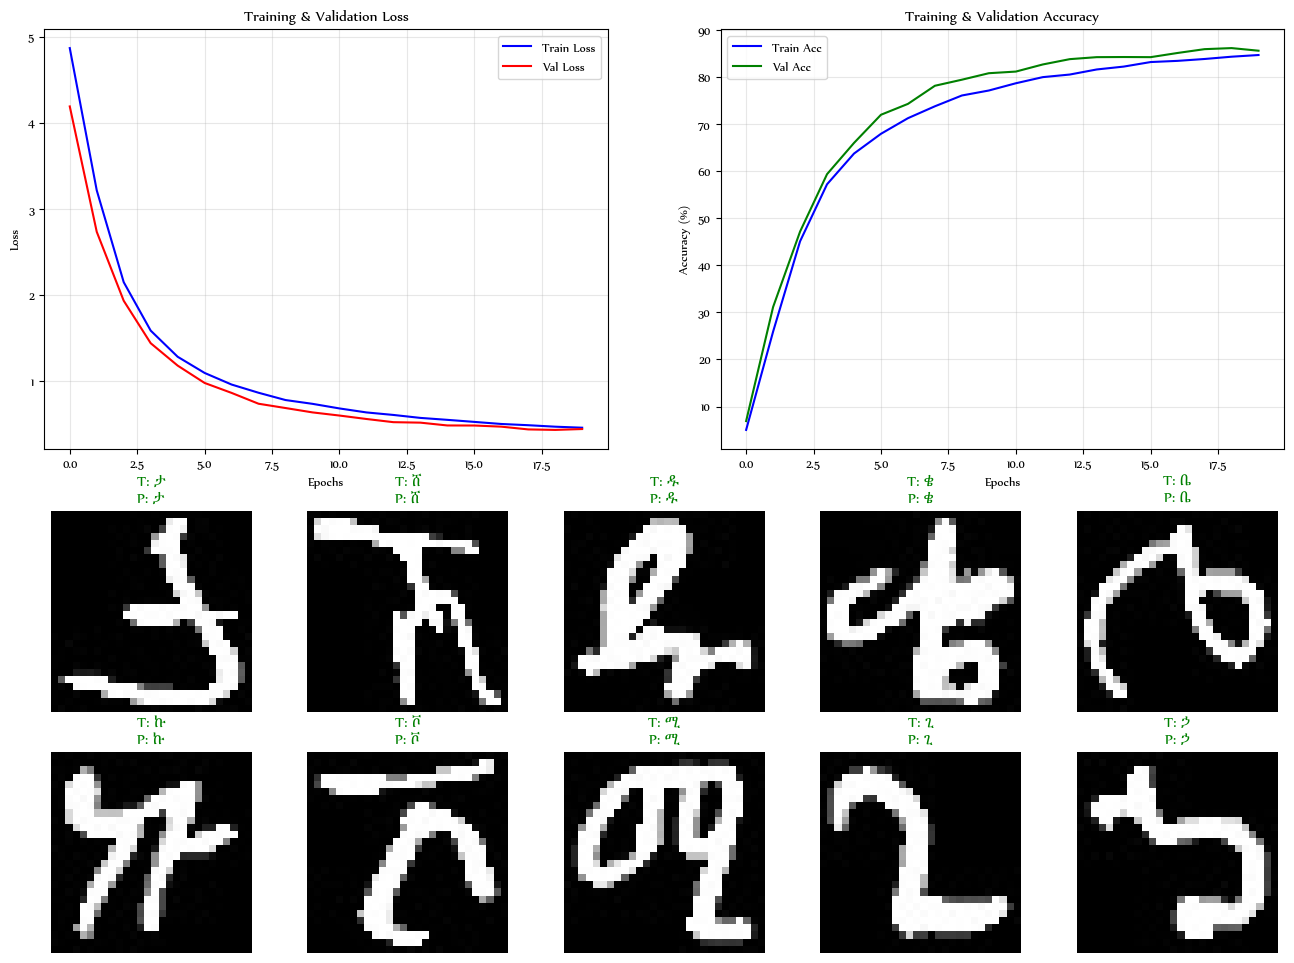

In [61]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import torch
import numpy as np

def master_evaluation_plot(history, model, loader, dataset_variable):
    """
    1. Sets Amharic-compatible font (Nyala for Windows).
    2. Plots Loss/Accuracy Curves.
    3. Plots Prediction Images below.
    """
    
    # --- FIX 1: SET FONT TO NYALA (Windows Standard) ---
    # This prevents the empty boxes []
    try:
        plt.rcParams['font.family'] = 'Nyala'
    except:
        print("Warning: Could not set Nyala font. Amharic chars might not show.")

    # Create a tall figure
    fig = plt.figure(figsize=(16, 12))
    
    # --- PART 1: THE CURVES (The "Dann Plot") ---
    
    # Loss Subplot
    plt.subplot(2, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', color='red')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Accuracy Subplot
    plt.subplot(2, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc', color='blue')
    plt.plot(history['val_acc'], label='Val Acc', color='green')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # --- PART 2: THE IMAGES (With Amharic Text) ---
    
    # Auto-detect class mapping (Subset fix)
    if hasattr(dataset_variable, 'class_to_idx'):
        class_map = dataset_variable.class_to_idx
    elif hasattr(dataset_variable, 'dataset') and hasattr(dataset_variable.dataset, 'class_to_idx'):
        class_map = dataset_variable.dataset.class_to_idx
    else:
        raise AttributeError("Could not find class_to_idx!")

    idx_to_class = {v: k for k, v in class_map.items()}
    
    # Get Batch
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    images = images.cpu()
    preds = preds.cpu()
    labels = labels.cpu()

    # Plot 10 images in the bottom half
    # We use subplot indices 5 through 14
    for i in range(10):
        if i >= len(images): break
        
        ax = plt.subplot(4, 5, i + 11) # Offset to bottom rows
        
        img = images[i][0] * 0.5 + 0.5
        ax.imshow(img, cmap='gray')
        
        true_txt = idx_to_class[labels[i].item()]
        pred_txt = idx_to_class[preds[i].item()]
        
        is_correct = (labels[i] == preds[i])
        color = 'green' if is_correct else 'red'
        
        ax.set_title(f"T: {true_txt}\nP: {pred_txt}", 
                     color=color, fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- EXECUTE ---
master_evaluation_plot(history, model, val_loader, train_dataset)

In [63]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [66]:
from sklearn.metrics import confusion_matrix
import torch
from collections import defaultdict
import numpy as np

cm = confusion_matrix(all_labels, all_preds)


In [67]:
confusions = []

for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:
            confusions.append((cm[i, j], i, j))

confusions.sort(reverse=True)
confusions[:10]


[(np.int64(20), 168, 210),
 (np.int64(17), 172, 214),
 (np.int64(10), 235, 104),
 (np.int64(10), 213, 171),
 (np.int64(10), 162, 161),
 (np.int64(9), 104, 235),
 (np.int64(8), 236, 233),
 (np.int64(8), 209, 167),
 (np.int64(8), 198, 24),
 (np.int64(8), 169, 211)]

In [68]:
import matplotlib.pyplot as plt

def show_mistakes(class_a, class_b, num=6):
    count = 0
    plt.figure(figsize=(10, 4))

    for img, label in zip(val_dataset, all_labels):
        image, true_label = img
        pred = model(image.unsqueeze(0).to(device)).argmax().item()

        if true_label == class_a and pred == class_b:
            plt.subplot(1, num, count+1)
            plt.imshow(image.squeeze(), cmap="gray")
            plt.axis("off")
            count += 1
            if count == num:
                break


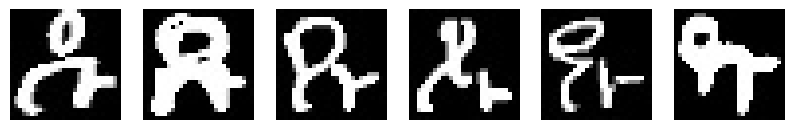

In [69]:
a, b = confusions[0][1], confusions[0][2]
show_mistakes(a, b)


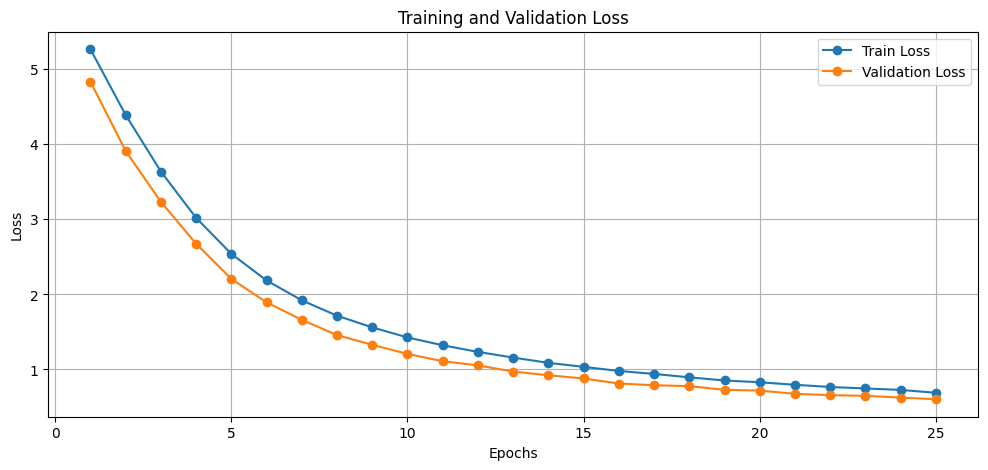

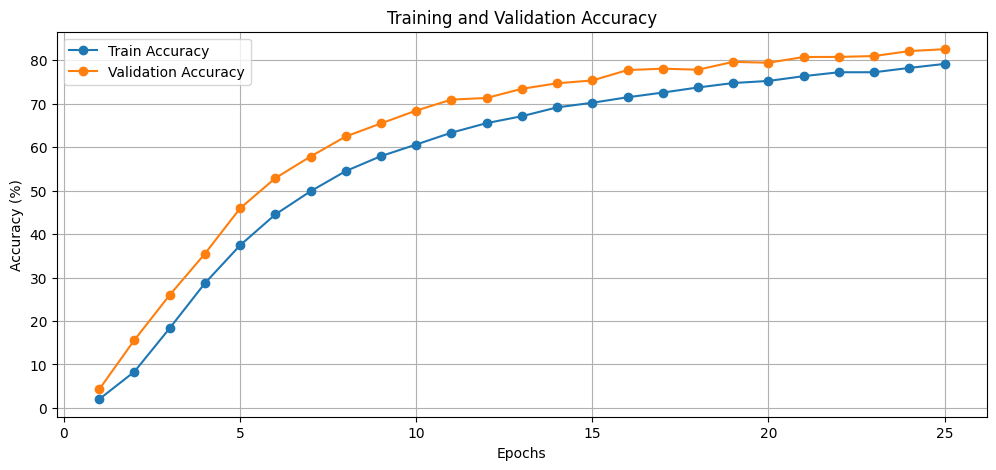

In [62]:
import os

def save_final_model(model, dataset, save_path="amharic_ocr_v2_85acc.pth"):
    
    # 1. Get the class mapping
    # Handle the 'Subset' wrapper issue one last time to be safe
    if hasattr(dataset, 'class_to_idx'):
        class_map = dataset.class_to_idx
    elif hasattr(dataset, 'dataset') and hasattr(dataset.dataset, 'class_to_idx'):
        class_map = dataset.dataset.class_to_idx
    else:
        print("⚠️ Warning: Could not save class mapping. You will need to recreate it manually.")
        class_map = None

    # 2. Create the checkpoint dictionary
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'class_to_idx': class_map,
        'input_shape': (1, 28, 28),
        'model_architecture': '4_Block_CNN_256_Features',
        'final_accuracy': 85.62
    }
    
    # 3. Save
    torch.save(checkpoint, save_path)
    print(f"✅ SUCCESS: Model saved to {os.path.abspath(save_path)}")
    print(f"📦 Contains {len(class_map)} classes.")

# Execute
save_final_model(model, train_dataset)

✅ SUCCESS: Model saved to C:\Users\XPS\amharic_ocr_v2_85acc.pth
📦 Contains 237 classes.
